In [ ]:
%pip install puremacro


# Diferencias-en-Diferencias Sintéticas — Unificando Control Sintético y TWFE

**¿Cómo evaluar una política que afectó a una sola unidad cuando fallan las tendencias paralelas y los donantes de control difieren de la unidad tratada?**
Dos de los diseños de evaluación causal más usados en economía empírica son:
1. **Diferencias en Diferencias (DiD)**: supone que los resultados potenciales no tratados siguen tendencias paralelas en el tiempo, con efectos fijos aditivos de unidad y de tiempo.
2. **Control Sintético (SC)**: abandona las tendencias paralelas y busca ponderaciones no negativas $\omega$ de donantes que reproduzcan la trayectoria pre-tratamiento de la unidad tratada. SC no tiene intercepto, así que debe igualar el *nivel* de la unidad tratada desde dentro de la envolvente convexa de los donantes, y sumar una constante al resultado de una unidad cambia su respuesta.

Dmitry Arkhangelsky, Susan Athey, David Hirshberg, Guido Imbens y Stefan Wager (2021, *American Economic Review*) combinan ambos en las **Diferencias en Diferencias Sintéticas (SDID)**: ponderaciones de unidades como en SC, ponderaciones temporales que hacen el mismo trabajo entre períodos, y los efectos fijos de DiD.

Este cuaderno usa **datos simulados**: una unidad tratada, 15 donantes, 20 períodos, un efecto plantado de −4.5 y un factor común al que las unidades están expuestas con distintas cargas, de modo que fallan las tendencias paralelas. Ajustamos `puremacro.did.synthetic_did`, leemos su error estándar e intervalo placebo, y en *Tu turno* comprobamos si el intervalo al 90% cubre el efecto plantado el 90% de las veces.

## El método en matemáticas

Sea $Y_{it}$ el resultado de la unidad $i$ en el período $t$. Una unidad es tratada desde el
período $T_0$ ($T_{pre}$ períodos antes, $T_{post}$ después); los $N_{co}$ donantes nunca lo son.
Escribimos $Y_{tr,t}$ para la trayectoria tratada y $\bar Y_{i,\text{post}}$ para la media
post-tratamiento de una unidad.

**Ponderaciones de unidades** (ec. 2.1 del artículo): un control sintético con intercepto
$\omega_0$ y una penalización ridge, $\zeta = (N_{tr}T_{post})^{1/4}\hat\sigma$, con $\hat\sigma$
la desviación estándar de los cambios de un período de los donantes antes del tratamiento
(ec. 2.2):
$$ (\hat\omega_0,\hat\omega) = \arg\min_{\omega_0,\ \omega\in\Delta} \sum_{t<T_0}\Big(\omega_0 + \sum_{i\in co}\omega_i Y_{it} - Y_{tr,t}\Big)^2 + \zeta^2 T_{pre}\,\|\omega\|_2^2 .$$
**Ponderaciones temporales** (ec. 2.3): el mismo problema entre períodos, ajustado solo con los
donantes,
$$ (\hat\lambda_0,\hat\lambda) = \arg\min_{\lambda_0,\ \lambda\in\Delta} \sum_{i\in co}\Big(\lambda_0 + \sum_{t<T_0}\lambda_t Y_{it} - \bar Y_{i,\text{post}}\Big)^2 .$$
**Estimación**:
$$ \hat\tau = \Big(\bar Y_{tr,\text{post}} - \sum_i \hat\omega_i \bar Y_{i,\text{post}}\Big) - \sum_{t<T_0}\hat\lambda_t\Big(Y_{tr,t} - \sum_i\hat\omega_i Y_{it}\Big). $$
Con $\omega$ y $\lambda$ uniformes se obtiene el DiD $2\times2$; sin el intercepto y sin el término
pre-tratamiento se obtiene SC (p. 4). Gracias a los interceptos, las ponderaciones de unidades
solo necesitan que la trayectoria de los donantes sea *paralela* a la tratada, y $\hat\tau$ no
cambia cuando se suma una constante a los resultados de cualquier unidad o período, como en DiD y
a diferencia de SC (p. 20). Usar ambos conjuntos de ponderaciones da lo que los autores llaman
"un tipo de doble robustez": si las ponderaciones de unidades o las temporales equilibran la
estructura latente de factores, su sesgo se elimina aproximadamente (p. 20).

**Inferencia con una unidad tratada** (Sección 5). El estimador **placebo** (Algoritmo 4)
asigna el tratamiento a un donante elegido al azar, reestima SDID solo con los donantes, repite, y
toma la varianza $\hat V$ de esas estimaciones placebo; el intervalo al 90% es
$\hat\tau \pm z_{0.95}\sqrt{\hat V}$ (ec. 5.1). Supone que el ruido de la unidad tratada se parece
al de los donantes (homocedasticidad entre unidades), algo que el artículo considera en la
práctica necesario para cualquier inferencia con una sola unidad tratada (p. 29). El bootstrap
por unidades (Algoritmo 2) y el jackknife (Algoritmo 3) no se usan aquí: el artículo no reporta
ninguno de los dos para $N_{tr}=1$ "porque los estimadores no están bien definidos" (nota del
Cuadro 4, p. 30). Con una sola unidad tratada, toda muestra bootstrap contiene esa misma unidad,
así que el remuestreo solo hace variar a los donantes y el ruido propio de la unidad tratada nunca
entra en el error estándar.

**Intuición.** El factor de esta simulación es un ciclo económico que golpea a las unidades con
distinta fuerza. DiD compara la unidad tratada con el donante promedio y por eso supone igual
exposición; SC busca donantes con la misma exposición *y* el mismo nivel. SDID solo pide la misma
exposición (el intercepto absorbe los niveles), y sus ponderaciones temporales eligen los
períodos pre-tratamiento en los que el ciclo estaba donde está, en promedio, después del
tratamiento. Las diferencias tomadas respecto de esos períodos cancelan la parte del ciclo que
las ponderaciones de unidades no igualaron.

Los números de página y de ecuación remiten a arXiv:1812.09970v4 (julio de 2021), la versión del
artículo del AER consultada para este cuaderno.

## Preparación — una intervención de política simulada con donantes no paralelos

$y_{it} = a_i + \text{trend}_t + \ell_i f_t + \varepsilon_{it}$, con $f_t$ un factor común con
forma de seno, cargas $\ell_i \sim U(0.5, 2)$ para los donantes y $\ell_0 = 1.4$ para la unidad
tratada, $\varepsilon_{it}\sim N(0, 0.4^2)$, y $\tau = -4.5$ sumado a la unidad tratada desde
$t = 12$.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import synthetic_did
from puremacro.synthetic_control import synthetic_control

N_donors = 15
N_units = N_donors + 1  # Unit 0 is treated
T_periods = 20
T_treat = 12

# Common latent factors
time_trend = np.linspace(10, 25, T_periods)
macro_factor = np.sin(np.linspace(0, 3 * np.pi, T_periods)) * 3.0

tau_true = -4.5      # planted treatment effect after T_treat
NOISE_SD = 0.4


def simulate(seed, load0=1.4):
    """Simulated panel and loadings; unit 0 is treated and has factor loading load0."""
    rng = np.random.default_rng(seed)
    unit_fixed_effects = rng.uniform(5, 20, size=N_units)
    factor_loadings = rng.uniform(0.5, 2.0, size=N_units)
    factor_loadings[0] = load0
    records = []
    for i in range(N_units):
        for t in range(T_periods):
            y_it = unit_fixed_effects[i] + time_trend[t] + factor_loadings[i] * macro_factor[t]
            y_it += rng.normal(0, NOISE_SD)
            if (i == 0) and (t >= T_treat):
                y_it += tau_true
            records.append({
                "unit": f"unit_{i:02d}",
                "time": t,
                "y": y_it,
                "treat_time": T_treat if i == 0 else np.nan,
            })
    return pd.DataFrame(records), factor_loadings


df_panel, factor_loadings = simulate(2021)
print(f"Simulated panel: {N_units} units ({N_donors} donors) x {T_periods} periods; "
      f"treated from t = {T_treat}; planted tau = {tau_true:+.1f}")
print(f"factor loadings: treated {factor_loadings[0]:.2f}; donors "
      f"{factor_loadings[1:].min():.2f} to {factor_loadings[1:].max():.2f} "
      f"(mean {factor_loadings[1:].mean():.2f})")

Simulated panel: 16 units (15 donors) x 20 periods; treated from t = 12; planted tau = -4.5
factor loadings: treated 1.40; donors 0.53 to 1.70 (mean 1.13)


## Estimación de DiD Sintético con puremacro

Con una unidad tratada, `se_method="auto"` elige el estimador de varianza placebo; `n_boot` es el
número de réplicas placebo. También calculamos el DiD $2\times2$ simple y el control sintético de
Abadie sobre el mismo panel.

In [2]:
res_sdid = synthetic_did(
    df=df_panel,
    unit="unit",
    time="time",
    outcome="y",
    treat_time="treat_time",
    n_boot=100,
    seed=42,
)
assert res_sdid.se_method == "placebo"   # Algorithm 4: the choice for one treated unit
print(res_sdid.summary())

covers = res_sdid.lo <= tau_true <= res_sdid.hi
print(f"planted tau = {tau_true:+.3f}; error {res_sdid.tau - tau_true:+.3f} "
      f"= {(res_sdid.tau - tau_true) / res_sdid.se:+.2f} placebo s.e.; "
      f"does the 90% CI contain it? {covers}")

assert abs(res_sdid.tau - tau_true) < 1.0
assert np.isclose(res_sdid.omega.sum(), 1.0) and (res_sdid.omega >= 0).all()
assert np.isclose(res_sdid.lambda_w.sum(), 1.0) and (res_sdid.lambda_w >= 0).all()

# Units invariance: measuring the outcome in units 1000 times smaller multiplies tau-hat by 1000.
# (Up to puremacro 4.3.0 the weight solver fell back to uniform weights, i.e. plain DiD,
# for outcomes in large units.)
tau_x1000 = synthetic_did(df_panel.assign(y=1000 * df_panel["y"]), n_boot=0).tau
print(f"outcome x 1000: tau-hat / 1000 = {tau_x1000 / 1000:.4f}")
assert np.isclose(tau_x1000, 1000 * res_sdid.tau, rtol=1e-6)

# The same panel through the two parent designs.
piv = df_panel.pivot(index="time", columns="unit", values="y")
treated_traj = piv["unit_00"].to_numpy()
donor_matrix = piv.drop(columns=["unit_00"]).to_numpy()
unweighted_control_path = donor_matrix.mean(axis=1)
gap_did = treated_traj - unweighted_control_path
did = gap_did[T_treat:].mean() - gap_did[:T_treat].mean()          # plain 2x2 DiD
sc = synthetic_control(piv, "unit_00", list(range(T_treat)),
                       list(range(T_treat, T_periods)), placebo=False).treatment_effect.mean()
print(pd.DataFrame({"estimate": [did, sc, res_sdid.tau]},
                   index=["DiD (2x2)", "SC (Abadie)", "SDID"])
      .assign(error=lambda d: d["estimate"] - tau_true).round(3).to_string())

Synthetic-DiD result
  treatment time    : 12.0
  donor units       : 15
  pre-period weights: 12
  τ̂                 : -4.0827 (se 0.2599)
  90% CI            : [-4.5102, -3.6552]
  se method         : placebo (Algorithm 4), 100 replications

planted tau = -4.500; error +0.417 = +1.61 placebo s.e.; does the 90% CI contain it? True
outcome x 1000: tau-hat / 1000 = -4.0827
             estimate  error
DiD (2x2)      -3.917  0.583
SC (Abadie)    -4.184  0.316
SDID           -4.083  0.417


## Figura principal — el contrafactual de SDID

A la trayectoria de donantes ponderada por $\hat\omega$ solo se le pide correr *paralela* a la
unidad tratada antes del tratamiento. Al sumarle la brecha pre-tratamiento ponderada por
$\hat\lambda$ se convierte en el contrafactual de SDID, y $\hat\tau$ es la brecha promedio
post-tratamiento entre la trayectoria tratada y ese contrafactual (verificado abajo con una
aserción, un control de consistencia interna de las líneas graficadas). El contrafactual de DiD
hace lo mismo con ponderaciones uniformes. El panel (b) muestra las ponderaciones temporales.

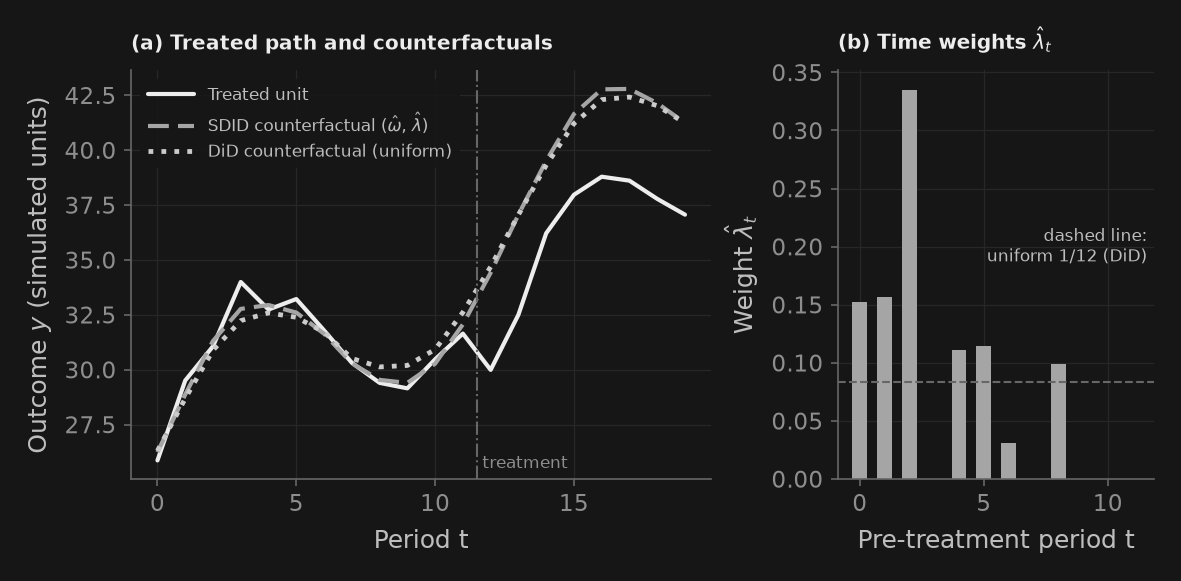

In [3]:
omega = res_sdid.omega.to_numpy()
lam = res_sdid.lambda_w.to_numpy()
synthetic_path = donor_matrix @ omega
sdid_cf = synthetic_path + lam @ (treated_traj - synthetic_path)[:T_treat]
did_cf = unweighted_control_path + gap_did[:T_treat].mean()
assert np.isclose((treated_traj - sdid_cf)[T_treat:].mean(), res_sdid.tau)
assert np.isclose((treated_traj - did_cf)[T_treat:].mean(), did)

fig, axes = _nbstyle.figura(ancho=7.6, alto=3.6, ncols=2, gridspec_kw={"width_ratios": [2.2, 1.2]})

# Panel 1: treated path and the two counterfactuals
ax = axes[0]
time_axis = np.arange(T_periods)
ax.plot(time_axis, treated_traj, **_nbstyle.S1, label="Treated unit")
ax.plot(time_axis, sdid_cf, **_nbstyle.S2, label=r"SDID counterfactual ($\hat\omega$, $\hat\lambda$)")
ax.plot(time_axis, did_cf, **_nbstyle.S4, label="DiD counterfactual (uniform)")
ax.axvline(T_treat - 0.5, color=_nbstyle.SPINE, ls="-.", lw=1.0)
ax.text(T_treat - 0.3, ax.get_ylim()[0] + 0.5, "treatment", color=_nbstyle.NOTA, fontsize=8)
ax.set_title("(a) Treated path and counterfactuals", loc="left", fontsize=9.5, fontweight="bold")
ax.set_xlabel("Period t")
ax.set_ylabel("Outcome $y$ (simulated units)")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: time weights
ax_w = axes[1]
pre_times = np.arange(T_treat)
ax_w.bar(pre_times, lam, color=_nbstyle.S2["color"], width=0.6)
ax_w.axhline(1.0 / T_treat, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_w.text(T_treat - 0.4, 0.2, f"dashed line:\nuniform 1/{T_treat} (DiD)", ha="right",
          va="center", color=_nbstyle.TEXTO, fontsize=8)
ax_w.set_title(r"(b) Time weights $\hat{\lambda}_t$", loc="left", fontsize=9.5, fontweight="bold")
ax_w.set_xlabel("Pre-treatment period t")
ax_w.set_ylabel(r"Weight $\hat{\lambda}_t$")

## Qué hacen las ponderaciones temporales

Salvo ruido, la trayectoria no tratada de la unidad tratada difiere de cualquier combinación de
donantes en un nivel y en (brecha de carga) $\times f_t$. Diferenciar respecto del pre-período
ponderado por $\hat\lambda$ deja un sesgo de factor de (brecha de carga)
$\times(\bar f_{post} - \hat\lambda' f_{pre})$; las ponderaciones uniformes de DiD dejan (brecha de
carga) $\times(\bar f_{post} - \bar f_{pre})$. La verificación de abajo usa el factor plantado, que
el estimador nunca ve.

In [4]:
f_pre, f_post = macro_factor[:T_treat], macro_factor[T_treat:].mean()
gap_sdid = factor_loadings[0] - omega @ factor_loadings[1:]
gap_mean = factor_loadings[0] - factor_loadings[1:].mean()
print(f"common factor f_t: post-period mean {f_post:+.3f}; lambda-weighted pre-period "
      f"{lam @ f_pre:+.3f}; plain pre-period mean {f_pre.mean():+.3f}")
print("largest time weights:", {int(t): round(float(w), 3) for t, w in res_sdid.lambda_w.nlargest(3).items()})
print("largest donor weights:", res_sdid.omega.nlargest(3).round(3).to_dict())
print(f"factor bias: DiD {gap_mean * (f_post - f_pre.mean()):+.3f} "
      f"(loading gap {gap_mean:+.2f}); SDID {gap_sdid * (f_post - lam @ f_pre):+.4f} "
      f"(loading gap {gap_sdid:+.2f})")

assert abs(lam @ f_pre - f_post) < 0.05        # the time weights balance the factor...
assert abs(f_pre.mean() - f_post) > 1.0        # ...which uniform pre-period weights do not

common factor f_t: post-period mean +1.380; lambda-weighted pre-period +1.377; plain pre-period mean +0.067
largest time weights: {2: 0.335, 1: 0.157, 0: 0.153}
largest donor weights: {'unit_01': 0.129, 'unit_11': 0.122, 'unit_02': 0.097}
factor bias: DiD +0.355 (loading gap +0.27); SDID +0.0002 (loading gap +0.07)


**Lectura de los resultados.** SDID estima $\hat\tau = -4.0827$ frente al $-4.5$ plantado, un
error de $+0.417$, o $+1.61$ errores estándar placebo ($\hat{\text{se}} = 0.2599$ con 100 réplicas
placebo). El intervalo al 90% $[-4.5102, -3.6552]$ contiene la verdad, pero por muy poco: esta
extracción es desafortunada, y un solo intervalo no dice nada sobre la cobertura (véase *Tu
turno*). Multiplicar el resultado por 1000 devuelve el mismo $-4.0827$ al dividir de nuevo: las
ponderaciones no dependen de las unidades. DiD falla por $+0.583$ y SC por $+0.316$; con esta
carga de la unidad tratada, SC resulta el más cercano.

Los sesgos de factor impresos explican el error de DiD. La carga de la unidad tratada (1.40)
supera la media de los donantes (1.13), así que el factor entra con más fuerza en la unidad
tratada, y DiD, que usa los doce pre-períodos por igual, compara el ciclo post-tratamiento
($+1.380$) con un promedio pre-tratamiento cercano a cero ($+0.067$): con una brecha de carga de
$+0.27$, un sesgo de factor de $+0.355$. Las ponderaciones temporales de SDID dan sus mayores pesos
a los períodos 2, 1 y 0 y ninguno a los tres últimos pre-períodos (panel b): al inicio de la
muestra el ciclo estaba donde está, en promedio, después del tratamiento. Así
$\hat\lambda' f_{pre} = +1.377$ y el sesgo de factor es $+0.0002$, aunque las ponderaciones de
unidades dejen una brecha de carga de $+0.07$. Lo que queda del error de SDID es ruido, sobre todo
el de la propia unidad tratada, que es lo que el error estándar placebo está diseñado para medir.
En el panel (a) ambos contrafactuales siguen la trayectoria tratada antes de $t = 12$, el de DiD
con menos precisión en los puntos de giro del ciclo, y después la trayectoria tratada cae por
debajo de ambos.

## Tu turno — ¿es el intervalo al 90% un intervalo al 90%?

Un solo intervalo no puede decirle su cobertura. Vuelva a simular el panel `R_YOU` veces
(semillas `0, 1, …`), ajuste SDID en cada uno y registre $\hat\tau$ y dos intervalos: el placebo
(el de omisión) y el bootstrap por unidades, sobre el que `synthetic_did` advierte cuando hay una
sola unidad tratada. La advertencia se silencia dentro del bucle solo porque ya la conocemos. Cada
panel usa 50 réplicas para cada método.

**Prediga primero:** ¿qué intervalo cubre el $-4.5$ plantado con más frecuencia, y qué error
estándar se acerca más a la desviación estándar Monte Carlo de $\hat\tau$?

In [5]:
def coverage(R, load0=1.4, n_boot=50):
    """Fit SDID on R simulated panels; placebo and bootstrap s.e. and 90% coverage."""
    rows = []
    for s in range(R):
        d, _ = simulate(s, load0)
        rp = synthetic_did(d, n_boot=n_boot, seed=42)                        # placebo (auto)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                                   # N_tr = 1 warning
            rb = synthetic_did(d, n_boot=n_boot, seed=42, se_method="bootstrap")
        rows.append({"tau": rp.tau, "se_placebo": rp.se, "se_boot": rb.se,
                     "cover_placebo": rp.lo <= tau_true <= rp.hi,
                     "cover_boot": rb.lo <= tau_true <= rb.hi})
    return pd.DataFrame(rows)


# ← Change this: number of simulated panels (try 40, 100 or 200; range 40 to 200, about 0.5 s each).
R_YOU = 40

mc = coverage(R_YOU)
sd_tau = mc["tau"].std(ddof=1)
mc_se = np.sqrt(0.90 * 0.10 / R_YOU)          # Monte Carlo s.e. of a 90% coverage rate
print(f"R = {R_YOU} panels: mean tau-hat {mc['tau'].mean():+.3f} (planted {tau_true:+.1f}); "
      f"Monte Carlo sd of tau-hat {sd_tau:.3f}")
print(pd.DataFrame({"mean se": [mc["se_placebo"].mean(), mc["se_boot"].mean()],
                    "coverage of 90% CI": [mc["cover_placebo"].mean(), mc["cover_boot"].mean()]},
                   index=["placebo (Algorithm 4)", "unit bootstrap"]).round(3).to_string())
print(f"Monte Carlo s.e. of a 90% coverage rate with R = {R_YOU}: {mc_se:.3f}")

# 1. tau-hat is centred on the planted effect.
assert abs(mc["tau"].mean() - tau_true) < 3 * sd_tau / np.sqrt(R_YOU)
# 2. The placebo interval covers at its nominal rate, up to Monte Carlo error.
assert abs(mc["cover_placebo"].mean() - 0.90) < 3 * mc_se
# 3. The bootstrap se omits the treated unit's own noise: too small, and it covers less.
assert mc["se_boot"].mean() < 0.75 * sd_tau
assert mc["cover_boot"].mean() < mc["cover_placebo"].mean()

R = 40 panels: mean tau-hat -4.470 (planted -4.5); Monte Carlo sd of tau-hat 0.230
                       mean se  coverage of 90% CI
placebo (Algorithm 4)    0.248               0.875
unit bootstrap           0.130               0.625
Monte Carlo s.e. of a 90% coverage rate with R = 40: 0.047


**Ejercicios.**

1. *Básico — una unidad tratada fuera del rango de los donantes.* Construya
   `df3, _ = simulate(2021, load0=3.0)` y calcule sobre él las tres estimaciones del código
   trabajado (pivote, DiD 2×2, `synthetic_control`, `synthetic_did(df3, n_boot=0).tau`). Ordénelas
   por distancia al efecto plantado y verifique
   `abs(sdid3 - tau_true) < abs(sc3 - tau_true) < abs(did3 - tau_true)`. Nombre el supuesto que
   falla para DiD (igual exposición, es decir, tendencias paralelas) y para SC (igualar el nivel y
   la trayectoria de la unidad tratada desde dentro de la envolvente convexa de los donantes, sin
   intercepto). Imprima los tres mayores $\hat\omega_i$: ¿por qué ninguna ponderación en el
   simplex puede reproducir una carga de 3.0? Con la carga base SC fue el más cercano (tabla de
   arriba), así que el orden es una propiedad de este diseño, no una ley.
2. *Intermedio — dónde mira $\hat\lambda$.* Compare `synthetic_did(df3, n_boot=0).lambda_w` con
   `res_sdid.lambda_w`. Son idénticas: ¿por qué? (Las ponderaciones temporales se ajustan solo con
   los donantes.) Subir la carga de la unidad tratada en $d\ell$ suma $d\ell\,f_t$ a su
   trayectoria. Escriba `did_at(l)`, el DiD 2×2 sobre
   `treated_traj + (l - factor_loadings[0]) * macro_factor`, y `tau_lam_at(l)`, que usa
   ponderaciones uniformes de donantes con las ponderaciones temporales de SDID
   (`gap = y - unweighted_control_path`, `tau = gap[T_treat:].mean() - lam @ gap[:T_treat]`).
   Derive ambas pendientes en $\ell$ en papel y luego verifique
   `np.isclose(did_at(3.0) - did_at(1.4), 1.6 * (f_post - f_pre.mean()))`,
   `np.isclose(tau_lam_at(3.0) - tau_lam_at(1.4), 1.6 * (f_post - lam @ f_pre))` y
   `abs(tau_lam_at(3.0) - tau_true) < 0.5 < 2.0 < abs(did_at(3.0) - tau_true)`.
3. *Avanzado — cuándo falla el intervalo placebo.* Corra `mc3 = coverage(R_YOU, load0=3.0)` en
   una celda nueva. Prediga primero: ¿cambia el error estándar placebo? Verifique
   `np.allclose(mc3["se_placebo"], mc["se_placebo"])` (se calcula solo con los donantes), luego
   compare `mc3["tau"].std()` con él y lea la cobertura. ¿Qué supuesto del Algoritmo 4 falla
   cuando la unidad tratada no se parece a ningún donante (p. 29)? Por último, dimensione la parte
   que el bootstrap omite en el caso base: el ruido propio de la unidad tratada aporta cerca de
   `NOISE_SD * np.sqrt(1 / (T_periods - T_treat) + (lam**2).sum())` a la desviación estándar de
   $\hat\tau$; compárelo con `np.sqrt(sd_tau**2 - mc["se_boot"].mean()**2)`.

## Idea clave

- Use **`synthetic_did`** para políticas regionales, estatales o de empresas cuando las
  tendencias paralelas son dudosas y se trata un puñado de unidades, o una sola. Conserva el
  emparejamiento de unidades de SC y la invariancia de DiD ante cambios de nivel, y sus
  ponderaciones temporales eliminan el sesgo de factor que dejan las ponderaciones de unidades.
- Con una sola unidad tratada, reporte el error estándar **placebo** y diga que supone que el
  ruido de la unidad tratada es como el de los donantes. `se_method="bootstrap"` requiere varias
  unidades tratadas.
- **¿Qué tan exhaustivo es esto?** `sdid_multi_cohort` extiende SDID a la adopción escalonada,
  `puremacro.synthetic_control` implementa el estimador de Abadie con brechas placebo
  (cuaderno 24), y el cuaderno 10 cubre DiD escalonado con Callaway-Sant'Anna y Sun-Abraham.